[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/pytorch-mastery/blob/main/06_end_to_end_projects/image_classification/image_classification.ipynb)


# 01 . Image Classification End to End (synthetic shapes + CNN)

## Concept — Image classification pipeline (revision notes)

**What it is**
- Take an image, output one label out of K classes. A CNN learns small
  reusable filters (edges, corners, blobs) and stacks them into shape detectors.
- An "end to end" project means every step you would ship: data, model,
  training, evaluation, error analysis, checkpoint, and an inference function.

**Why it matters**
- Most real vision problems reduce to this loop. Getting it right on a tiny
  synthetic task lets you debug the *pipeline* (shapes, normalisation,
  train/eval mode, checkpoint loading) without waiting hours on a GPU.
- A model that only works inside the notebook that trained it is not finished:
  the checkpoint + predict function is the actual deliverable.

**When to use**
- Fixed-size images with local structure -> convolutions beat MLPs through weight sharing.
- Use global average pooling when you want a head that works for any input size.

**Math & intuition**
- Conv layer: `out[c,y,x] = sum_{k,i,j} W[c,k,i,j] * in[k,y+i,x+j] + b[c]`. Same W everywhere
  = translation equivariance; pooling then gives approximate invariance.
- Loss: cross-entropy on logits, `-log softmax(z)[true class]`. Softmax is inside the loss; do not add it before.
- Check: a model at chance on K balanced classes has loss near `ln(K)` (about 1.386 for K=4).

### 1. Setup and imports

**What this cell does (plain language):** makes the project folder importable (also on Colab), imports torch and our small `data`, `model`, `train` modules, and fixes the random seed so every run is identical.

In [1]:
import os, sys, subprocess
# The notebook imports a small tested module that lives next to it.
# On Colab that folder is not there yet, so fetch the repo once and move into the project directory.
PROJECT = "06_end_to_end_projects/image_classification"
if not os.path.exists("data.py"):
    if not os.path.exists("PyTorch-Mastery"):
        subprocess.run(["git", "clone", "-q", "https://github.com/himanshu231204/PyTorch-Mastery"], check=False)
    if os.path.isdir("PyTorch-Mastery/" + PROJECT):
        os.chdir("PyTorch-Mastery/" + PROJECT)
sys.path.insert(0, os.getcwd())

import torch, torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
from data import make_dataset, train_val_split, CLASSES
from model import SmallCNN, save_checkpoint, load_checkpoint, Predictor
from train import fit, evaluate, confusion_matrix

torch.manual_seed(0)
print("torch", torch.__version__, "| classes:", CLASSES)

torch 2.14.1+cu130 | classes: ['circle', 'square', 'triangle', 'cross']


### 2. Generate synthetic shape images

**What this cell does (plain language):** draws 800 noisy 16x16 images of circles, squares, triangles and crosses at random positions and sizes. Synthetic data lets us know the ground truth exactly and means no downloads. We plot a grid to LOOK at the data before modelling - the cheapest bug-finder there is.

images: (800, 1, 16, 16) torch.float32 | labels: (800,) torch.int64
pixel range: 0.0 to 1.0


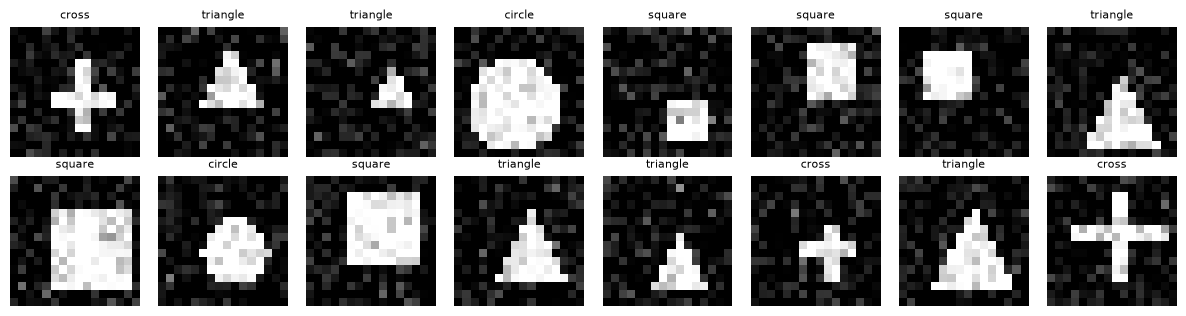

In [2]:
x, y = make_dataset(800, size=16, noise=0.15, seed=0)
print("images:", tuple(x.shape), x.dtype, "| labels:", tuple(y.shape), y.dtype)
print("pixel range:", x.min().item(), "to", x.max().item())

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, img, lab in zip(axes.flat, x[:16], y[:16]):
    ax.imshow(img[0], cmap="gray", vmin=0, vmax=1); ax.set_title(CLASSES[lab], fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

### 3. Split and sanity-check the data

**What this cell does (plain language):** splits into train/validation (75/25) and checks that classes are balanced in both parts. If one class were rare, plain accuracy would be misleading, so we check before training.

In [3]:
train, val = train_val_split(x, y, val_frac=0.25)
print("train:", train[0].shape, "val:", val[0].shape)
print("train class counts:", torch.bincount(train[1]).tolist())
print("val   class counts:", torch.bincount(val[1]).tolist())
print("chance accuracy:", 1 / len(CLASSES))

train: torch.Size([600, 1, 16, 16]) val: torch.Size([200, 1, 16, 16])
train class counts: [164, 146, 138, 152]
val   class counts: [36, 54, 62, 48]
chance accuracy: 0.25


### 4. Build the model and trace shapes

**What this cell does (plain language):** creates the CNN and pushes a dummy batch through each stage to print the tensor shapes. Shape-tracing catches most architecture bugs in seconds. We also count parameters to confirm the model is tiny.

In [4]:
model = SmallCNN(num_classes=len(CLASSES), width=8)
h = x[:2]
for layer in model.features:
    h = layer(h)
    if isinstance(layer, (nn.MaxPool2d,)):
        print(f"after {layer.__class__.__name__:10s}", tuple(h.shape))
print("after global avg pool:", tuple(h.mean(dim=(2, 3)).shape), "-> logits", tuple(model(x[:2]).shape))
print("parameters:", sum(p.numel() for p in model.parameters()))

after MaxPool2d  (2, 8, 8, 8)
after MaxPool2d  (2, 16, 4, 4)
after global avg pool: (2, 16) -> logits (2, 4)
parameters: 1364


### 5. Sanity check: overfit one small batch

**What this cell does (plain language):** before the real run we check the pipeline can drive loss to nearly zero on 16 images. If it cannot, there is a bug in the model, loss or optimiser wiring - no amount of data or epochs will fix that.

In [5]:
import torch.nn.functional as F
probe = SmallCNN()
opt = torch.optim.Adam(probe.parameters(), lr=1e-2)
xb, yb = train[0][:16], train[1][:16]
probe.train()
for step in range(60):
    opt.zero_grad(); loss = F.cross_entropy(probe(xb), yb); loss.backward(); opt.step()
    if step % 20 == 0 or step == 59:
        print(f"step {step:2d} loss {loss.item():.4f}")
print("initial loss should be near ln(4) =", round(float(torch.log(torch.tensor(4.0))), 3))

step  0 loss 1.3754
step 20 loss 0.2810


step 40 loss 0.0232
step 59 loss 0.0058
initial loss should be near ln(4) = 1.386


### 6. Train the real model

**What this cell does (plain language):** trains for 10 epochs with Adam and mini-batches of 32. Each epoch prints train loss, validation loss and validation accuracy. Validation numbers can jump around early on because BatchNorm running statistics are still settling; they stabilise as training goes on.

In [6]:
torch.manual_seed(0)
model = SmallCNN()
history = fit(model, train, val, epochs=10, lr=3e-3, seed=0)

epoch  1 | train loss 1.295 | val loss 1.297 | val acc 0.360
epoch  2 | train loss 1.065 | val loss 1.182 | val acc 0.275


epoch  3 | train loss 0.894 | val loss 0.869 | val acc 0.800
epoch  4 | train loss 0.724 | val loss 0.660 | val acc 0.915


epoch  5 | train loss 0.571 | val loss 0.516 | val acc 0.955
epoch  6 | train loss 0.410 | val loss 0.425 | val acc 0.945


epoch  7 | train loss 0.311 | val loss 0.245 | val acc 0.980


epoch  8 | train loss 0.225 | val loss 0.196 | val acc 0.995
epoch  9 | train loss 0.180 | val loss 0.177 | val acc 0.990


epoch 10 | train loss 0.145 | val loss 0.105 | val acc 1.000


### 7. Plot the learning curves

**What this cell does (plain language):** plots training loss against validation loss and validation accuracy. A widening gap between the two curves is the classic overfitting signature; both falling together means the model is still learning.

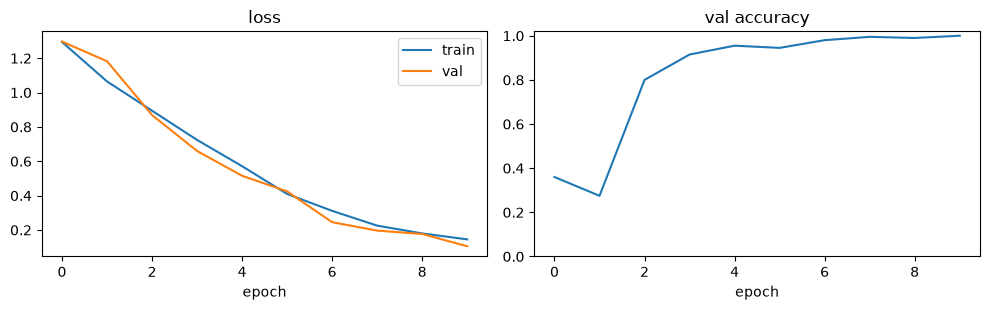

In [7]:
tl, vl, va = zip(*history)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(tl, label="train"); ax[0].plot(vl, label="val"); ax[0].set_title("loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(va); ax[1].set_title("val accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylim(0, 1.02)
plt.tight_layout(); plt.show()

### 8. Evaluate: accuracy, per-class accuracy, confusion matrix

**What this cell does (plain language):** runs the model in eval mode on the held-out set. The confusion matrix (rows = truth, columns = prediction) shows WHICH classes get mixed up, which a single accuracy number hides.

In [8]:
val_loss, val_acc, preds = evaluate(model, *val)
print(f"validation loss {val_loss:.3f} | accuracy {val_acc:.3f}")
cm = confusion_matrix(preds, val[1], len(CLASSES))
print("confusion matrix (rows=true, cols=pred):")
print(cm)
for i, c in enumerate(CLASSES):
    print(f"  {c:9s} accuracy: {cm[i, i].item() / cm[i].sum().item():.3f}")

validation loss 0.105 | accuracy 1.000
confusion matrix (rows=true, cols=pred):
tensor([[36,  0,  0,  0],
        [ 0, 54,  0,  0],
        [ 0,  0, 62,  0],
        [ 0,  0,  0, 48]])
  circle    accuracy: 1.000
  square    accuracy: 1.000
  triangle  accuracy: 1.000
  cross     accuracy: 1.000


### 9. Error analysis: look at the mistakes

**What this cell does (plain language):** shows validation images the model got wrong with true and predicted labels. If there are no mistakes we show the least confident correct predictions instead. Looking at failures tells you whether the fix is more data, a bigger model, or a data bug.

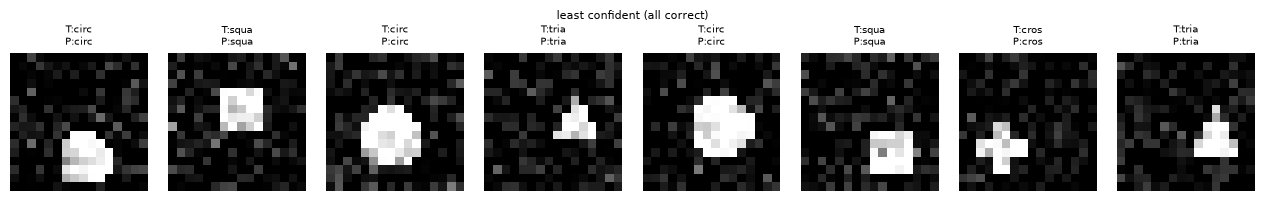

number of validation mistakes: 0


In [9]:
wrong = (preds != val[1]).nonzero().flatten()
if len(wrong) == 0:
    with torch.no_grad():
        conf = torch.softmax(model.eval()(val[0]), -1).max(-1).values
    idx = conf.argsort()[:8]; title = "least confident (all correct)"
else:
    idx = wrong[:8]; title = "mistakes"
fig, axes = plt.subplots(1, len(idx), figsize=(1.6 * len(idx), 2), squeeze=False)
for ax, i in zip(axes.flat, idx):
    ax.imshow(val[0][i, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"T:{CLASSES[val[1][i]][:4]}\nP:{CLASSES[preds[i]][:4]}", fontsize=7); ax.axis("off")
plt.suptitle(title, fontsize=8); plt.tight_layout(); plt.show()
print("number of validation mistakes:", len(wrong))

### 10. Save and reload a checkpoint

**What this cell does (plain language):** saves the weights together with the class names and architecture width, reloads into a fresh model and verifies the outputs match exactly. We store a plain dict (not the pickled model object) so the file survives code refactors, and load it with `weights_only=True` which is the safe loader.

In [10]:
save_checkpoint(model, "shapes_cnn.pt", val_acc=val_acc)
print("file size (KB):", round(os.path.getsize("shapes_cnn.pt") / 1024, 1))
reloaded, ck = load_checkpoint("shapes_cnn.pt")
model.eval()
with torch.no_grad():
    same = torch.allclose(model(val[0]), reloaded(val[0]), atol=1e-6)
print("reloaded model gives identical logits:", same, "| metadata:", ck["meta"])

file size (KB): 11.3
reloaded model gives identical logits: True | metadata: {'val_acc': 1.0}


### 11. Inference function and serving stub

**What this cell does (plain language):** wraps the checkpoint in a `Predictor` that accepts a plain nested list (like JSON from a web request), switches to inference mode, and returns a JSON-friendly dict with top-k probabilities. `handle_request` adds the validation a web route needs - bad input returns an error dict instead of crashing.

In [11]:
import json
predictor = Predictor("shapes_cnn.pt")
sample = val[0][0, 0].tolist()                       # a 16x16 nested list, as JSON would carry
print("true label :", CLASSES[val[1][0]])
print("prediction :", json.dumps(predictor.handle_request({"image": sample})))
print("bad request:", predictor.handle_request({"img": sample}))
print("bad shape  :", predictor.handle_request({"image": [[0.0] * 3] * 3}))

true label : cross
prediction : {"label": "cross", "top_k": [{"label": "cross", "prob": 0.8868}, {"label": "circle", "prob": 0.1056}]}
bad request: {'error': "missing 'image'"}
bad shape  : {'error': 'Given input size: (16x1x1). Calculated output size: (16x0x0). Output size is too small'}


### 12. Optional: expose it over HTTP (FastAPI)

**What this cell does (plain language):** if FastAPI is installed we show how the same `Predictor` becomes a web endpoint (we only define it, not start a server). If not, we just print the install hint - the notebook runs either way.

In [12]:
try:
    from fastapi import FastAPI
    app = FastAPI()

    @app.post("/predict")
    def predict(payload: dict):
        return predictor.handle_request(payload)

    print("FastAPI app defined. Serve with: uvicorn app_module:app --port 8000")
except ImportError:
    print("fastapi not installed (optional). Install with: pip install fastapi uvicorn")
os.remove("shapes_cnn.pt")   # keep the repo clean

fastapi not installed (optional). Install with: pip install fastapi uvicorn


## Common bugs

- **Forgetting `model.eval()` at inference** — fix: BatchNorm/Dropout behave as in training, predictions change per batch; always call `model.eval()` and use `torch.inference_mode()`.
- **Putting softmax before `CrossEntropyLoss`** — fix: the loss already applies log-softmax; feed raw logits and softmax only when reporting probabilities.
- **Train/inference preprocessing mismatch** — fix: if you normalise or resize at train time, do the identical transform in the predict function (here: add channel/batch dims and use the same [0,1] range).
- **Missing the batch/channel dimension** — fix: a single `(H,W)` image must become `(1,1,H,W)` before the conv; the Predictor does this explicitly.
- **Saving the whole model with `torch.save(model)`** — fix: this pickles class paths and breaks on refactors; save `state_dict` plus the config needed to rebuild, and load with `weights_only=True`.
- **Evaluating only accuracy** — fix: with imbalanced classes accuracy hides failures; inspect the confusion matrix and per-class recall.
- **Not shuffling the training data each epoch** — fix: batches then correlate with label order; shuffle with a seeded `Generator` (as `fit` does).
- **Leaking validation data into training** — fix: split BEFORE any fitting or augmentation statistics; never tune on the final test set.

## Exercises

**Exercise 1.** Add a 5th class (a horizontal bar) to `draw_shape` logic by writing your own `draw_bar(size, generator)` and check it renders.

In [13]:
# Your attempt for Exercise 1 here

**Solution 1**

In [14]:
# Solution 1
import torch
def draw_bar(size, g):
    cy = int(3 + torch.rand(1, generator=g).item() * (size - 6))
    img = torch.zeros(size, size); img[cy:cy+2, 2:size-2] = 1.0
    return img
print(draw_bar(16, torch.Generator().manual_seed(0)).sum().item(), "pixels lit")

24.0 pixels lit


**Exercise 2.** Increase the noise to 0.5 in `make_dataset`, retrain for 10 epochs and report validation accuracy. How does it change?

In [15]:
# Your attempt for Exercise 2 here

**Solution 2**

In [16]:
# Solution 2
xn, yn = make_dataset(800, noise=0.5, seed=1)
tr, va = train_val_split(xn, yn)
torch.manual_seed(0); m = SmallCNN(); fit(m, tr, va, epochs=10, verbose=False)
print("noisy val acc:", evaluate(m, *va)[1])

noisy val acc: 0.5450000166893005


**Exercise 3.** Compute precision and recall for the class `triangle` from the confusion matrix `cm`.

In [17]:
# Your attempt for Exercise 3 here

**Solution 3**

In [18]:
# Solution 3
k = CLASSES.index("triangle")
tp = cm[k, k].item(); precision = tp / max(cm[:, k].sum().item(), 1); recall = tp / max(cm[k].sum().item(), 1)
print("precision", precision, "recall", recall)

precision 1.0 recall 1.0


**Exercise 4.** Replace global average pooling with `Flatten` + `Linear(16*4*4 -> 4)`. Count parameters of both heads.

In [19]:
# Your attempt for Exercise 4 here

**Solution 4**

In [20]:
# Solution 4
flat_head = nn.Sequential(nn.Flatten(), nn.Linear(16 * 4 * 4, 4))
print("flatten head params:", sum(p.numel() for p in flat_head.parameters()), "| GAP head params:", sum(p.numel() for p in model.head.parameters()))

flatten head params: 1028 | GAP head params: 68


**Exercise 5.** Add a random horizontal-flip augmentation to the training loop only (not validation) and explain why it is safe for these classes.

In [21]:
# Your attempt for Exercise 5 here

**Solution 5**

In [22]:
# Solution 5
def flip_aug(xb):
    mask = torch.rand(len(xb)) < 0.5
    xb = xb.clone(); xb[mask] = xb[mask].flip(-1); return xb
# circle, square, cross are flip symmetric and our upward triangle is symmetric left/right, so labels are unchanged
print(flip_aug(val[0][:4]).shape)

torch.Size([4, 1, 16, 16])


**Exercise 6.** Make the Predictor return `unsure` when the top probability is below 0.6.

In [23]:
# Your attempt for Exercise 6 here

**Solution 6**

In [24]:
# Solution 6
def predict_with_threshold(pred, image, thr=0.6):
    out = pred.predict(image, top_k=1)
    return "unsure" if out["top_k"][0]["prob"] < thr else out["label"]
save_checkpoint(model, "tmp_ex.pt"); print(predict_with_threshold(Predictor("tmp_ex.pt"), val[0][0, 0].tolist())); os.remove("tmp_ex.pt")

cross
